# Iris Species Classification with Neural Network

This notebook demonstrates a complete machine learning workflow for classifying iris flower species using a feedforward neural network with Keras.

## 1. Import Libraries

In [17]:
# Core data processing and numerical computing libraries
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# Deep learning framework
from keras.models import Sequential
from keras.layers import Dense

## 2. Data Loading and Exploration

In [18]:
# Load the Iris dataset
df = pd.read_csv('https://drive.google.com/uc?id=1roJ83AbgzDcvRr0Gwud0BmdUQx-oSG-w')

# Display first 5 samples
print("Dataset Overview:")
print(df.head())

Dataset Overview:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [19]:
# Display dataset information
print("\nDataset Information:")
print(df.info())
print(f"\nDataset Shape: {df.shape}")
print(f"Classes: {sorted(df['Species'].unique())}")


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
None

Dataset Shape: (150, 6)
Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


## 3. Data Preprocessing

In [20]:
# Remove the ID column as it is not a feature
df = df.drop(columns='Id')
print("ID column removed")

ID column removed


In [21]:
# One-hot encode the categorical target variable
# Convert species labels to binary vectors for neural network training
category = pd.get_dummies(df.Species, dtype=int)
print("One-hot encoded target variable:")
print(category.head())

One-hot encoded target variable:
   Iris-setosa  Iris-versicolor  Iris-virginica
0            1                0               0
1            1                0               0
2            1                0               0
3            1                0               0
4            1                0               0


In [22]:
# Combine encoded labels with features and remove original species column
new_df = pd.concat([df, category], axis=1)
new_df = new_df.drop(columns='Species')
print(f"\nCombined dataframe shape: {new_df.shape}")
print(new_df.head())


Combined dataframe shape: (150, 7)
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Iris-setosa  \
0            5.1           3.5            1.4           0.2            1   
1            4.9           3.0            1.4           0.2            1   
2            4.7           3.2            1.3           0.2            1   
3            4.6           3.1            1.5           0.2            1   
4            5.0           3.6            1.4           0.2            1   

   Iris-versicolor  Iris-virginica  
0                0               0  
1                0               0  
2                0               0  
3                0               0  
4                0               0  


In [23]:
# Convert dataframe to numpy array for model input
dataset = new_df.values
print(f"Dataset array shape: {dataset.shape}")

Dataset array shape: (150, 7)


## 4. Feature-Target Separation and Normalization

In [24]:
# Separate features (X) and labels (y)
# Features: first 4 columns (Sepal Length, Sepal Width, Petal Length, Petal Width)
# Labels: last 3 columns (one-hot encoded species)
X = dataset[:, 0:4]  # Input features
y = dataset[:, 4:7]  # Target labels

print(f"Features (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")

Features (X) shape: (150, 4)
Labels (y) shape: (150, 3)


In [25]:
# Apply Min-Max normalization to scale features to [0, 1] range
# Normalization improves neural network training and convergence
min_max_scaler = preprocessing.MinMaxScaler()
X_scale = min_max_scaler.fit_transform(X)

print(f"Normalized features - Min: {X_scale.min():.4f}, Max: {X_scale.max():.4f}")
print(f"\nFirst 5 normalized samples:")
print(X_scale[:5])

Normalized features - Min: 0.0000, Max: 1.0000

First 5 normalized samples:
[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


## 5. Train-Test Split

In [26]:
# Split data into training (70%) and testing (30%) sets
# This allows unbiased evaluation of model performance on unseen data
X_train, X_test, Y_train, Y_test = train_test_split(
    X_scale, y, test_size=0.3, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Train-Test Ratio: {X_train.shape[0]/X_test.shape[0]:.2f}:1")

Training samples: 105
Testing samples: 45
Train-Test Ratio: 2.33:1


## 6. Model Architecture

In [27]:
# Build a sequential neural network model
# Architecture:
# - Input Layer: 4 features
# - Hidden Layer 1: 64 neurons with ReLU activation
# - Hidden Layer 2: 64 neurons with ReLU activation
# - Output Layer: 3 neurons with Softmax activation (multi-class probabilities)

model = Sequential([
    Dense(64, activation='relu', input_shape=(4,)),  # Hidden layer 1
    Dense(64, activation='relu'),                     # Hidden layer 2
    Dense(3, activation='softmax')                    # Output layer
])

print("Model Architecture:")
model.summary()

Model Architecture:


c:\VSCode Project\iris-classifier\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,675 (18.26 KB)

 Trainable params: 4,675 (18.26 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Model Compilation

In [28]:
# Compile the model with appropriate optimizer, loss, and metrics
# - Optimizer: Adam (Adaptive Moment Estimation) - adaptive learning rate
# - Loss: Categorical Crossentropy - standard loss for multi-class classification
# - Metrics: Accuracy - fraction of correct predictions

model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


## 8. Model Training

In [29]:
# Train the model on training data
# Epochs: number of complete passes through the training dataset (100)
# Batch Size: number of samples processed before updating weights (32)
# Verbose: 1 shows progress bar

print("Starting model training...")
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    verbose=1
)

print("\nTraining completed!")

Starting model training...
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3524 - loss: 0.9970  
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3619 - loss: 0.9616 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5048 - loss: 0.9313 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6095 - loss: 0.9028 
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6286 - loss: 0.8747 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6476 - loss: 0.8490 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6476 - loss: 0.8186 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6476 - loss: 0.7912 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6476 - loss: 0.7621 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6476 - loss: 0.7347 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6476 - loss: 0.7075 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/s

## 9. Model Evaluation

In [30]:
# Evaluate the trained model on unseen test data
# This provides an unbiased assessment of model performance

test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print("="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)
print(f"\nTest Loss:     {test_loss:.6f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Samples:  {X_test.shape[0]}")
print(f"Correct Predictions: {int(test_accuracy * X_test.shape[0])}/{X_test.shape[0]}")

MODEL EVALUATION ON TEST SET

Test Loss:     0.062658
Test Accuracy: 97.78%
Test Samples:  45
Correct Predictions: 44/45


In [31]:
# Make predictions on first 10 test samples
# Display predicted probabilities for each iris species

predictions = model.predict(X_test[:10])
species_names = ['Iris-Setosa', 'Iris-Versicolor', 'Iris-Virginica']

print("\n" + "="*70)
print("SAMPLE PREDICTIONS (First 10 Test Samples)")
print("="*70)

for i, pred in enumerate(predictions):
    predicted_class = species_names[np.argmax(pred)]
    confidence = pred[np.argmax(pred)] * 100
    print(f"\nSample {i+1}:")
    print(f"  Predicted: {predicted_class} (Confidence: {confidence:.2f}%)")
    print(f"  Probabilities: Setosa={pred[0]:.4f}, Versicolor={pred[1]:.4f}, Virginica={pred[2]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

SAMPLE PREDICTIONS (First 10 Test Samples)

Sample 1:
  Predicted: Iris-Versicolor (Confidence: 97.19%)
  Probabilities: Setosa=0.0009, Versicolor=0.9719, Virginica=0.0272

Sample 2:
  Predicted: Iris-Setosa (Confidence: 99.60%)
  Probabilities: Setosa=0.9960, Versicolor=0.0040, Virginica=0.0000

Sample 3:
  Predicted: Iris-Virginica (Confidence: 99.97%)
  Probabilities: Setosa=0.0000, Versicolor=0.0003, Virginica=0.9997

Sample 4:
  Predicted: Iris-Versicolor (Confidence: 87.32%)
  Probabilities: Setosa=0.0005, Versicolor=0.8732, Virginica=0.1263

Sample 5:
  Predicted: Iris-Versicolor (Confidence: 87.19%)
  Probabilities: Setosa=0.0002, Versicolor=0.8719, Virginica=0.1279

Sample 6:
  Predicted: Iris-Setosa (Confidence: 99.19%)
  Probabilities: Setosa=0.9919, Versicolor=0.0081, Virginica=0.0000

Sample 7:
  Predicted: Iris-Versicolor (Confidence: 98.39%)
  Probabilities: Setosa=0.0061, Versicolor=0.9839, Virginica=0.0100

Sample 8:
  Predicted: 

In [34]:
import matplotlib.pyplot as plt

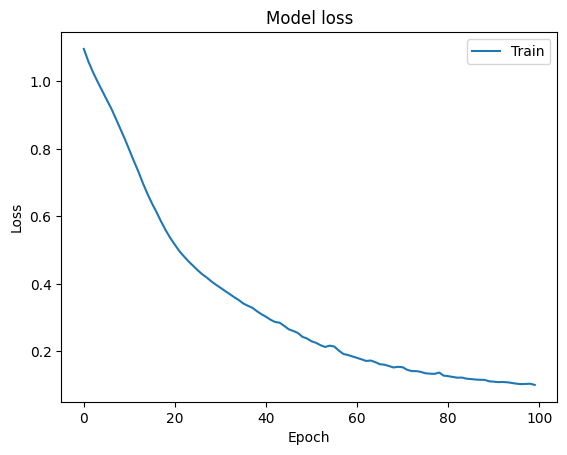

In [ ]:
# Visualization of Model loss
plt.plot(hist.history['loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')
plt.show()

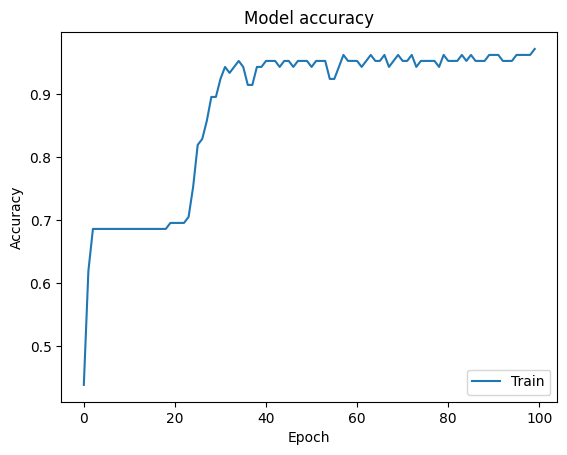

In [39]:
# Visualization of Model accuracy
plt.plot(hist.history['accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='lower right')
plt.show()